# Dense periodic n=1 volatility forecasting

## Step 4 objective

Construct three one-step conditional volatility forecasts from training-only observable estimates. This notebook stops at forecast construction and mechanical validation; it deliberately performs no Step 5 accuracy, ranking, calibration, or interval analysis.


## 2. Forecast timing and information set

The forecast for $\sigma_{i+1}$ is issued after $S_{i+1}$ is observed, while $\sigma_i$ remains known and before the delayed observation of $\sigma_{i+1}$. It is therefore a one-step conditional volatility forecast (or conditional volatility nowcast), not an ordinary ex-ante forecast from $t_i$. Allowed transition-$i$ inputs are $S_i$, $S_{i+1}$, $\sigma_i$, $\Delta t_i$, the event calendar, the event age, and training-fitted parameters.


## 3. Governing forecast equations

For $n=1$, $m_{i+1}=\sqrt{\omega_{i+1}}$, so each forecast is $\widehat\sigma_{i+1}=\widehat m_{i+1}\widehat F_i$; no second square root is applied to $\widehat m$. The common observable background estimates $\widehat F_i=\hat\beta_0+\hat\beta_\sigma\sigma_i+\hat\beta_\epsilon\widehat\epsilon_i$, where $\widehat\epsilon_i=((S_{i+1}-S_i)/S_i)/\sigma_i$. Step 3 supplies the frozen event profiles: the parametric multiplier is $\sqrt{1+\hat A\exp(-\hat\lambda a/\mathrm{steps\ per\ year})}$ and the non-parametric multiplier is the Step 3 RF-derived active-training cell mean at age $a$.

The latent $\eta_i$ term in $F_i=\sigma_i+\alpha_i\Delta t_i+\nu_i[\rho_i\epsilon_i+\sqrt{1-\rho_i^2}\eta_i]$ is not forecastable. Its conditional mean is zero, so the OLS baseline estimates the observable conditional-mean contribution without reconstructing $\eta_i$, realised hidden $F_i$, or true event quantities.


## 4. Load frozen Step 3 profiles and imports


In [1]:
%%capture
%run "./03_dense_periodic_n1_event_weight_estimation.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option('display.precision', 6)

upstream_notebooks = ['03_dense_periodic_n1_event_weight_estimation.ipynb']

# Freeze the fitted Step 3 event-response objects immediately after the upstream run.
step3_A_hat = float(A_hat)
step3_lambda_hat = float(lambda_hat)
step3_parametric_multiplier_by_age = pd.Series(
    exponential_multiplier(np.asarray(event_transition_ages) / steps_per_year, step3_A_hat, step3_lambda_hat),
    index=event_transition_ages, name='step3_parametric_multiplier', dtype=float,
)
step3_nonparametric_multiplier_by_age = age_profile['mean'].copy().astype(float)
step3_nonparametric_multiplier_by_age.name = 'step3_nonparametric_multiplier'
step3_event_profiles_frozen = True
step5_outputs_created = []


## 5. Inherit the dense periodic n=1 benchmark from Step 3

Notebook 03 already executes Notebook 00 and builds the aligned sample, chronological split, and training-fitted event profiles. Step 4 reuses those objects directly and does not rerun the simulator.


In [2]:
model_params = reference_config['model']
steps_per_year = reference_timing['steps_per_year']
event_transition_ages = list(reference_timing['event_transition_ages'])
if model_params['n'] != 1 or reference_timing['event_responses_overlap']:
    raise ValueError('Notebook 04 requires the non-overlapping dense periodic n=1 Step 3 configuration.')
assert step3_event_profiles_frozen
assert step3_parametric_multiplier_by_age.index.tolist() == event_transition_ages
assert step3_nonparametric_multiplier_by_age.index.tolist() == event_transition_ages
print(f'Inherited Step 3 benchmark with {len(analysis_table)} usable transitions.')


Inherited Step 3 benchmark with 492 usable transitions.


## 6. Reuse the aligned observable forecasting table

The Step 3 table is retained unchanged. Age zero is the event affecting transition $i\to i+1$ and hence $\sigma_{i+1}$.


In [3]:
step3_analysis_index = analysis_table.index.copy()
event_features = [f'event_lag_{age}' for age in event_transition_ages]
required_observable_columns = ['S_i', 'S_next', 'sigma_i', 'sigma_next', 'simple_return_i', 'epsilon_proxy_i', *event_features]
assert analysis_table[required_observable_columns].notna().all().all()
assert analysis_table.loc[analysis_table['event_active_i'].eq(0), 'event_age_years_i'].isna().all()
assert set(analysis_table.loc[analysis_table['event_active_i'].eq(1), 'event_age_i'].astype(int)) == set(event_transition_ages)
print(f'Reused Step 3 table: {len(analysis_table)} usable rows; {int(analysis_table.event_active_i.sum())} active rows.')
display(analysis_table.head())


Reused Step 3 table: 492 usable rows; 299 active rows.


,i,target_i,t_i,dt_i,S_i,S_next,sigma_i,sigma_next,event_i,simple_return_i,...,event_lag_11,event_lag_12,event_active_i,event_age_i,event_age_years_i,F_hat_parametric,F_hat_nonparametric,omega_hat_parametric,omega_hat_nonparametric,true_omega_next
0,12,13,0.047619,0.003968,102.751010,102.087857,0.195601,0.195878,0,-0.006454,...,0,0,0,NaN,NaN,0.195954,0.195663,1.0,1.0,1.0
1,13,14,0.051587,0.003968,102.087857,102.490211,0.195878,0.196371,0,0.003941,...,0,0,0,NaN,NaN,0.195827,0.196103,1.0,1.0,1.0
2,14,15,0.055556,0.003968,102.490211,101.771270,0.196371,0.195697,0,-0.007015,...,0,0,0,NaN,NaN,0.196739,0.196775,1.0,1.0,1.0
3,15,16,0.059524,0.003968,101.771270,100.296205,0.195697,0.195363,0,-0.014494,...,0,0,0,NaN,NaN,0.196360,0.195904,1.0,1.0,1.0
4,16,17,0.063492,0.003968,100.296205,100.888858,0.195363,0.194100,0,0.005909,...,0,0,0,NaN,NaN,0.195240,0.195220,1.0,1.0,1.0


## 7. Preserve the Step 3 chronological train-test split

The Step 3 chronological split is reused exactly: earlier rows are training and the test sample begins at the first subsequent age-zero event.


In [4]:
step3_train_i = train_data['i'].copy()
step3_test_i = test_data['i'].copy()
assert train_data['t_i'].max() < test_data['t_i'].min()
assert int(test_data['event_lag_0'].iloc[0]) == 1
for age in event_transition_ages:
    assert (train_data['event_age_i'].eq(age)).any() and (test_data['event_age_i'].eq(age)).any()
split_summary = pd.DataFrame([{
    'training_rows': len(train_data), 'testing_rows': len(test_data),
    'test_start_i': int(test_data['i'].iloc[0]), 'test_start_t': float(test_data['t_i'].iloc[0]),
    'training_active_rows': int(train_data['event_active_i'].sum()),
    'testing_active_rows': int(test_data['event_active_i'].sum()),
}])
display(split_summary)


,training_rows,testing_rows,test_start_i,test_start_t,training_active_rows,testing_active_rows
0,345,147,357,1.416667,208,91


## 8. Freeze the common event-free OLS background

All three primary forecasts use the Step 3 OLS baseline, fitted only on event-free training transitions. This common deployment background avoids confounding the event-profile comparison with the random forest's chronological extrapolation weakness.


In [5]:
baseline_feature_columns = ['sigma_i', 'epsilon_proxy_i']
hidden_simulator_names = {'epsilon', 'eta', 'F', 'omega', 'omega_next', 'true_omega', 'true_omega_next', 'true_amplitude', 'true_decay_rate'}
event_free_train = train_data.loc[train_data['event_active_i'].eq(0)].copy()
step4_ols_baseline = ols_baseline
frozen_ols_coefficients = step4_ols_baseline.params.copy()
ols_coefficients = frozen_ols_coefficients.rename('estimate').to_frame()
assert set(baseline_feature_columns).isdisjoint(hidden_simulator_names)
print(ols_coefficients.to_string())

def ols_baseline_prediction(frame):
    return np.asarray(step4_ols_baseline.predict(sm.add_constant(frame[baseline_feature_columns], has_constant='add')), dtype=float)

analysis_table['F_hat_ols'] = ols_baseline_prediction(analysis_table)
if not np.isfinite(analysis_table['F_hat_ols']).all() or not analysis_table['F_hat_ols'].gt(0).all():
    raise ValueError('The OLS baseline produced a non-finite or non-positive conditional forecast.')


                 estimate
const            0.001754
sigma_i          0.991565
epsilon_proxy_i -0.007568


## 9. Step 3 event profiles carried forward without refitting

Step 3 estimates both event-weight profiles. Step 4 carries those frozen outputs forward: the parametric profile uses Step 3's $\hat A$ and $\hat\lambda$, and the non-parametric profile is exactly Step 3's RF-derived cell-mean multiplier profile. No raw multiplier is reconstructed and no event profile is refitted here.


In [6]:
step4_event_profile_refit_attempted = False
assert step3_event_profiles_frozen and not step4_event_profile_refit_attempted
assert 'm_raw' not in train_data.columns and 'm_raw' not in test_data.columns
np.testing.assert_allclose(
    step3_parametric_multiplier_by_age.to_numpy(),
    exponential_multiplier(np.asarray(event_transition_ages) / steps_per_year, step3_A_hat, step3_lambda_hat),
    rtol=0.0, atol=1e-12,
)
np.testing.assert_allclose(
    step3_nonparametric_multiplier_by_age.to_numpy(), age_profile['mean'].loc[event_transition_ages].to_numpy(),
    rtol=0.0, atol=1e-12,
)
assert train_data['i'].tolist() == step3_train_i.tolist() and test_data['i'].tolist() == step3_test_i.tolist()


## 10. Step 3 parametric profile

The deployed parametric multipliers are the Step 3 fitted function $m^P(a)=\sqrt{1+\hat A\exp(-\hat\lambda a)}$, evaluated once at the configured event ages. Step 4 performs no nonlinear optimisation.


In [7]:
step3_parametric_omega_by_age = step3_parametric_multiplier_by_age ** 2
assert np.isfinite(step3_parametric_omega_by_age).all() and step3_parametric_omega_by_age.gt(0).all()
print(f'Step 3 parametric profile: A_hat={step3_A_hat:.8g}; lambda_hat={step3_lambda_hat:.8g}.')


Step 3 parametric profile: A_hat=0.0084031238; lambda_hat=36.058112.


## 11. Step 3 non-parametric profile

The deployed non-parametric multiplier is precisely Notebook 03's RF-derived active-training cell mean, $\mathtt{age\_profile['mean']}$, without smoothing, clipping, monotonicity enforcement, or recalculation from the OLS background.


In [8]:
step3_nonparametric_omega_by_age = step3_nonparametric_multiplier_by_age ** 2
assert np.isfinite(step3_nonparametric_omega_by_age).all() and step3_nonparametric_omega_by_age.gt(0).all()
display(pd.DataFrame({
    'parametric_multiplier': step3_parametric_multiplier_by_age,
    'nonparametric_multiplier': step3_nonparametric_multiplier_by_age,
    'nonparametric_omega': step3_nonparametric_omega_by_age,
}))


,parametric_multiplier,nonparametric_multiplier,nonparametric_omega
0,1.004193,1.003706,1.007426
1,1.003635,1.002728,1.005463
2,1.003151,1.004128,1.008273
3,1.002731,1.005145,1.010316
4,1.002368,1.003255,1.006520
5,1.002052,1.003098,1.006205
6,1.001779,1.002845,1.005698
7,1.001542,1.001601,1.003205
8,1.001337,1.001647,1.003298
9,1.001158,1.001556,1.003114


## 12. Freeze all pre-test forecast components

The common OLS background coefficients and both Step 3 profiles are copied before any test forecast is generated. This hybrid construction deliberately combines the Step 3 RF-derived event-response profile with the common OLS event-free background; it is not a whole-forecast random forest. For $n=1$, $m=\sqrt{\omega}$, so $\widehat\sigma=\widehat m\widehat F$ with no second square root.


In [9]:
frozen_A_hat = float(step3_A_hat)
frozen_lambda_hat = float(step3_lambda_hat)
frozen_step3_parametric_profile = step3_parametric_multiplier_by_age.copy()
frozen_step3_nonparametric_profile = step3_nonparametric_multiplier_by_age.copy()
assert frozen_step3_parametric_profile.index.tolist() == event_transition_ages
assert frozen_step3_nonparametric_profile.index.tolist() == event_transition_ages
assert np.isfinite([frozen_A_hat, frozen_lambda_hat]).all() and frozen_A_hat >= 0 and frozen_lambda_hat >= 0
np.testing.assert_allclose(frozen_step3_parametric_profile, step3_parametric_multiplier_by_age, rtol=0.0, atol=1e-12)
np.testing.assert_allclose(frozen_step3_nonparametric_profile, age_profile['mean'].loc[event_transition_ages], rtol=0.0, atol=1e-12)


## 13. Construct the three test forecast variants

The dedicated forecast-input table deliberately excludes $\sigma_{i+1}$. For active rows it applies the frozen Step 3 multiplier at the event age; event-free rows use multiplier one. The RF is used only for the Step 3 non-parametric event-response estimate, never as the deployed Step 4 background.


In [10]:
forecast_input_columns = [
    'i', 'target_i', 't_i', 'dt_i', 'S_i', 'S_next', 'sigma_i', 'simple_return_i',
    'epsilon_proxy_i', 'event_i', 'event_active_i', 'event_age_i', 'event_age_years_i',
]
test_forecast_table = test_data[forecast_input_columns].copy()
assert 'sigma_next' not in test_forecast_table.columns
assert set(forecast_input_columns).isdisjoint(hidden_simulator_names)

test_forecast_table['F_hat_ols'] = ols_baseline_prediction(test_forecast_table)
if not np.isfinite(test_forecast_table['F_hat_ols']).all() or not test_forecast_table['F_hat_ols'].gt(0).all():
    raise ValueError('A test OLS baseline forecast is non-finite or non-positive.')
active = test_forecast_table['event_active_i'].eq(1)
test_forecast_table['multiplier_hat_unaware'] = 1.0
test_forecast_table['multiplier_hat_parametric'] = 1.0
test_forecast_table.loc[active, 'multiplier_hat_parametric'] = test_forecast_table.loc[active, 'event_age_i'].map(frozen_step3_parametric_profile)
test_forecast_table['multiplier_hat_nonparametric'] = 1.0
test_forecast_table.loc[active, 'multiplier_hat_nonparametric'] = test_forecast_table.loc[active, 'event_age_i'].map(frozen_step3_nonparametric_profile)
test_forecast_table['omega_hat_parametric'] = test_forecast_table['multiplier_hat_parametric'] ** 2
test_forecast_table['omega_hat_nonparametric'] = test_forecast_table['multiplier_hat_nonparametric'] ** 2
test_forecast_table['sigma_forecast_unaware'] = test_forecast_table['F_hat_ols']
test_forecast_table['sigma_forecast_parametric'] = test_forecast_table['multiplier_hat_parametric'] * test_forecast_table['F_hat_ols']
test_forecast_table['sigma_forecast_nonparametric'] = test_forecast_table['multiplier_hat_nonparametric'] * test_forecast_table['F_hat_ols']
assert test_forecast_table.drop(columns=['event_age_i', 'event_age_years_i']).notna().all().all()
assert test_forecast_table.loc[test_forecast_table['event_active_i'].eq(0), ['event_age_i', 'event_age_years_i']].isna().all().all()
assert test_forecast_table.loc[~active, ['multiplier_hat_unaware', 'multiplier_hat_parametric', 'multiplier_hat_nonparametric']].eq(1.0).all().all()
assert np.isfinite(test_forecast_table[['F_hat_ols', 'omega_hat_parametric', 'omega_hat_nonparametric', 'sigma_forecast_unaware', 'sigma_forecast_parametric', 'sigma_forecast_nonparametric']].to_numpy()).all()
assert test_forecast_table[['F_hat_ols', 'omega_hat_parametric', 'omega_hat_nonparametric', 'sigma_forecast_unaware', 'sigma_forecast_parametric', 'sigma_forecast_nonparametric']].gt(0).all().all()


## 14. Forecast mechanics tables and plots

The true synthetic event multiplier is shown only after all estimators are frozen, as a reference that was never used for fitting or forecasting. Realised $\sigma_{i+1}$ is retrieved separately only after forecast construction for a qualitative illustration. It contains the unpredictable $\eta_i$ innovation, whereas the forecasts estimate a conditional mean; exact path matching is neither expected nor required. No accuracy metric is calculated here.


,test_forecasts,active_test_rows,event_free_test_rows,configured_event_ages,OLS_baseline_features
0,147,91,56,13,"sigma_i, epsilon_proxy_i"


,i,target_i,t_i,dt_i,S_i,S_next,sigma_i,simple_return_i,epsilon_proxy_i,event_i,...,event_age_years_i,F_hat_ols,multiplier_hat_unaware,multiplier_hat_parametric,multiplier_hat_nonparametric,omega_hat_parametric,omega_hat_nonparametric,sigma_forecast_unaware,sigma_forecast_parametric,sigma_forecast_nonparametric
345,357,358,1.416667,0.003968,94.821470,92.715920,0.241007,-0.022205,-0.092136,1,...,0.000000,0.241425,1.0,1.004193,1.003706,1.008403,1.007426,0.241425,0.242437,0.242319
346,358,359,1.420635,0.003968,92.715920,92.541011,0.241906,-0.001887,-0.007799,0,...,0.003968,0.241678,1.0,1.003635,1.002728,1.007283,1.005463,0.241678,0.242557,0.242337
347,359,360,1.424603,0.003968,92.541011,91.204517,0.241951,-0.014442,-0.059690,0,...,0.007937,0.242116,1.0,1.003151,1.004128,1.006312,1.008273,0.242116,0.242878,0.243115
348,360,361,1.428571,0.003968,91.204517,92.045389,0.242894,0.009220,0.037957,0,...,0.011905,0.242311,1.0,1.002731,1.005145,1.005470,1.010316,0.242311,0.242973,0.243558
349,361,362,1.432540,0.003968,92.045389,92.343123,0.243580,0.003235,0.013280,0,...,0.015873,0.243178,1.0,1.002368,1.003255,1.004741,1.006520,0.243178,0.243754,0.243970
350,362,363,1.436508,0.003968,92.343123,93.926772,0.244098,0.017150,0.070257,0,...,0.019841,0.243261,1.0,1.002052,1.003098,1.004109,1.006205,0.243261,0.243760,0.244014
351,363,364,1.440476,0.003968,93.926772,92.327254,0.244718,-0.017029,-0.069588,0,...,0.023810,0.244934,1.0,1.001779,1.002845,1.003561,1.005698,0.244934,0.245369,0.245630
352,364,365,1.444444,0.003968,92.327254,91.685959,0.244380,-0.006946,-0.028422,0,...,0.027778,0.244287,1.0,1.001542,1.001601,1.003086,1.003205,0.244287,0.244664,0.244678
353,365,366,1.448413,0.003968,91.685959,88.205200,0.243240,-0.037964,-0.156076,0,...,0.031746,0.244123,1.0,1.001337,1.001647,1.002675,1.003298,0.244123,0.244450,0.244525
354,366,367,1.452381,0.003968,88.205200,89.010514,0.243907,0.009130,0.037432,0,...,0.035714,0.243320,1.0,1.001158,1.001556,1.002318,1.003114,0.243320,0.243602,0.243699


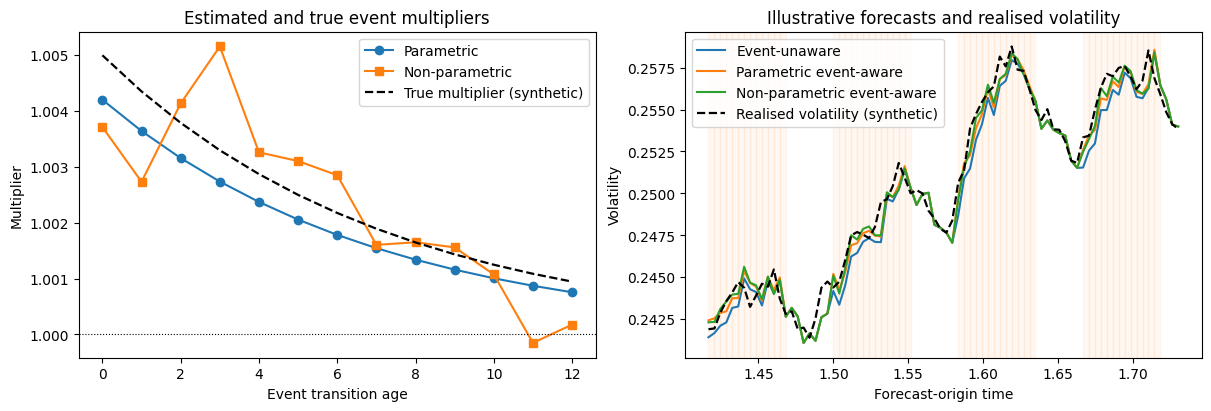

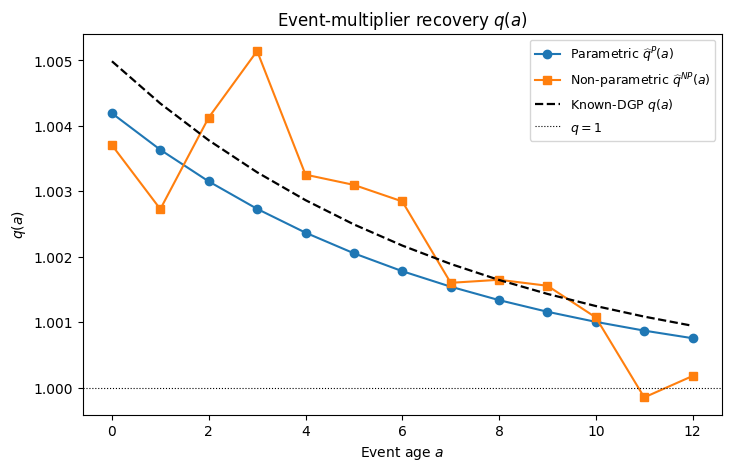

Figure 4.2 uses exactly the existing left-panel event ages and profile values.


In [11]:
forecast_mechanics_summary = pd.DataFrame([{
    'test_forecasts': len(test_forecast_table),
    'active_test_rows': int(active.sum()),
    'event_free_test_rows': int((~active).sum()),
    'configured_event_ages': len(event_transition_ages),
    'OLS_baseline_features': ', '.join(baseline_feature_columns),
}])
display(forecast_mechanics_summary)
display(test_forecast_table.head(12))

# Synthetic truth is accessed only after fitting and frozen forecast generation.
true_event_amplitude = reference_config['events']['amplitude']
true_decay_rate = reference_config['events']['decay_rate']
profile_plot = pd.DataFrame({
    'event_age': event_transition_ages,
    'parametric_multiplier': frozen_step3_parametric_profile.loc[event_transition_ages].to_numpy(),
    'nonparametric_multiplier': frozen_step3_nonparametric_profile.loc[event_transition_ages].to_numpy(),
})
profile_plot['true_multiplier_synthetic'] = np.sqrt(
    1.0 + true_event_amplitude * np.exp(-true_decay_rate * profile_plot['event_age'] / steps_per_year)
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(profile_plot['event_age'], profile_plot['parametric_multiplier'], marker='o', label='Parametric')
axes[0].plot(profile_plot['event_age'], profile_plot['nonparametric_multiplier'], marker='s', label='Non-parametric')
axes[0].plot(profile_plot['event_age'], profile_plot['true_multiplier_synthetic'], color='black', linestyle='--', linewidth=1.6, label='True multiplier (synthetic)')
axes[0].axhline(1.0, color='black', linewidth=0.8, linestyle=':')
axes[0].set(title='Estimated and true event multipliers', xlabel='Event transition age', ylabel='Multiplier')
axes[0].legend()

segment = test_forecast_table.head(min(80, len(test_forecast_table))).copy()
# The realised target is aligned only after all forecasts exist; it never enters the forecast-input table.
realised_segment = test_data.set_index('i').loc[segment['i'], 'sigma_next'].to_numpy()
for column, label in [
    ('sigma_forecast_unaware', 'Event-unaware'),
    ('sigma_forecast_parametric', 'Parametric event-aware'),
    ('sigma_forecast_nonparametric', 'Non-parametric event-aware'),
]:
    axes[1].plot(segment['t_i'], segment[column], label=label)
axes[1].plot(segment['t_i'], realised_segment, color='black', linestyle='--', linewidth=1.6, label='Realised volatility (synthetic)')
for _, row in segment.loc[segment['event_active_i'].eq(1)].iterrows():
    axes[1].axvspan(row['t_i'], row['t_i'] + row['dt_i'], color='tab:orange', alpha=0.05)
axes[1].set(title='Illustrative forecasts and realised volatility', xlabel='Forecast-origin time', ylabel='Volatility')
axes[1].legend()
plt.show()


# Dissertation-facing Figure 4.2: direct reuse of the left-panel profile coordinates.
from pathlib import Path
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

standalone_event_ages = profile_plot['event_age'].to_numpy(copy=True)
standalone_parametric_q = profile_plot['parametric_multiplier'].to_numpy(copy=True)
standalone_nonparametric_q = profile_plot['nonparametric_multiplier'].to_numpy(copy=True)
standalone_known_q = profile_plot['true_multiplier_synthetic'].to_numpy(copy=True)

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
ax.plot(
    standalone_event_ages, standalone_parametric_q,
    marker='o', label=r'Parametric $\widehat{q}^{P}(a)$',
)
ax.plot(
    standalone_event_ages, standalone_nonparametric_q,
    marker='s', label=r'Non-parametric $\widehat{q}^{NP}(a)$',
)
ax.plot(
    standalone_event_ages, standalone_known_q,
    color='black', linestyle='--', linewidth=1.6,
    label=r'Known-DGP $q(a)$',
)
ax.axhline(1.0, color='black', linewidth=0.8, linestyle=':', label=r'$q=1$')
ax.set(
    title=r'Event-multiplier recovery $q(a)$',
    xlabel=r'Event age $a$',
    ylabel=r'$q(a)$',
)
ax.legend(fontsize=9)
fig.savefig(
    FIGURE_DIR / 'fig_4_2_event_multiplier_recovery.pdf',
    bbox_inches='tight',
)
plt.show()

np.testing.assert_array_equal(standalone_event_ages, profile_plot['event_age'].to_numpy())
np.testing.assert_array_equal(standalone_parametric_q, profile_plot['parametric_multiplier'].to_numpy())
np.testing.assert_array_equal(standalone_nonparametric_q, profile_plot['nonparametric_multiplier'].to_numpy())
np.testing.assert_array_equal(standalone_known_q, profile_plot['true_multiplier_synthetic'].to_numpy())
print('Figure 4.2 uses exactly the existing left-panel event ages and profile values.')


## 15. Final Step 4 findings and handoff to Step 5

Three mechanically valid conditional-volatility forecast variants have been constructed with a common training-only OLS baseline. Step 3 estimates the parametric and non-parametric event-weight profiles, and Step 4 freezes and carries them forward. The non-parametric forecast is deliberately hybrid: its event-response profile is RF-derived in Step 3, while its deployed event-free background is the common OLS forecast. The latent $\eta_i$ innovation remains irreducible. No recursive forecast, Step 5 accuracy or calibration analysis is performed here. Step 5 may evaluate the completed forecast columns against delayed realised volatility.


In [12]:
print('Step 4 verification')
print(f'Step 3 A_hat/lambda_hat used: {frozen_A_hat:.8g}, {frozen_lambda_hat:.8g}.')
print(f'Step 3 non-parametric event-age cells carried forward: {len(frozen_step3_nonparametric_profile)}.')
print('Both Step 3 profiles match the profiles used in Step 4: yes.')
print(f'Training/testing rows: {len(train_data)}/{len(test_data)}; forecasts created: {len(test_forecast_table)}.')
print('Common forecast background: OLS event-free baseline.')
print('Step 4 event-profile refitting occurred: no.')
print('All integrity assertions passed; no Step 5 forecast-accuracy, ranking, or calibration evaluation was performed.')


Step 4 verification
Step 3 A_hat/lambda_hat used: 0.0084031238, 36.058112.
Step 3 non-parametric event-age cells carried forward: 13.
Both Step 3 profiles match the profiles used in Step 4: yes.
Training/testing rows: 345/147; forecasts created: 147.
Common forecast background: OLS event-free baseline.
Step 4 event-profile refitting occurred: no.
All integrity assertions passed; no Step 5 forecast-accuracy, ranking, or calibration evaluation was performed.
